# Análise Exploratória

## Célula 1: Importação e Setup

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Configuração para os gráficos aparecerem no Jypiter Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

# Carregar o dataset unificado
df = pd.read_csv('ETL/Dados Tratados/Dados Unificados/dataset_final_modelagem.csv')

## Célula 2: Visão Geral e Medidas de Tendência Central

In [31]:
# Filtrando apenas colunas numéricas de interesse
colunas_estudo = [
    'populacao', 'pib_per_capita', 'target_perc_utilitarios', 
    'target_perc_diesel', 'pib_agro_por_habitante', 'presenca_rodovia_federal'
]

# Estatísticas descritivas (Média, Mediana, Desvio Padrão, Quartis)
resumo_estatistico = df[colunas_estudo].describe().transpose()

# Moda
resumo_estatistico['moda'] = df[colunas_estudo].mode().iloc[0]

resumo_estatistico

,count,mean,std,min,25%,50%,75%,max,moda
populacao,5571.0,3.645320e+04,2.065008e+05,0.0,5.223000e+03,1.106400e+04,2.442650e+04,1.145200e+07,2946.0
pib_per_capita,5571.0,3.053921e+06,4.082023e+06,0.0,1.078226e+06,2.023352e+06,3.808747e+06,9.208284e+07,809043.0
target_perc_utilitarios,5571.0,7.582911e-01,6.117161e-01,0.0,3.731879e-01,6.091371e-01,9.750995e-01,7.497251e+00,0.0
target_perc_diesel,5571.0,9.529342e+00,3.897709e+00,0.0,6.905593e+00,8.986139e+00,1.157650e+01,7.608142e+01,0.0
pib_agro_por_habitante,5571.0,8.220508e+03,1.680568e+04,0.0,9.740683e+02,2.829232e+03,9.230908e+03,3.135688e+05,0.0
presenca_rodovia_federal,5571.0,1.992461e-02,1.397538e-01,0.0,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.0


## Célula 3: Análise de Distribuição (Histogramas)

Abaixo analisamos a distribuição das variáveis para entender a concentração de riqueza e tipos de veículos.

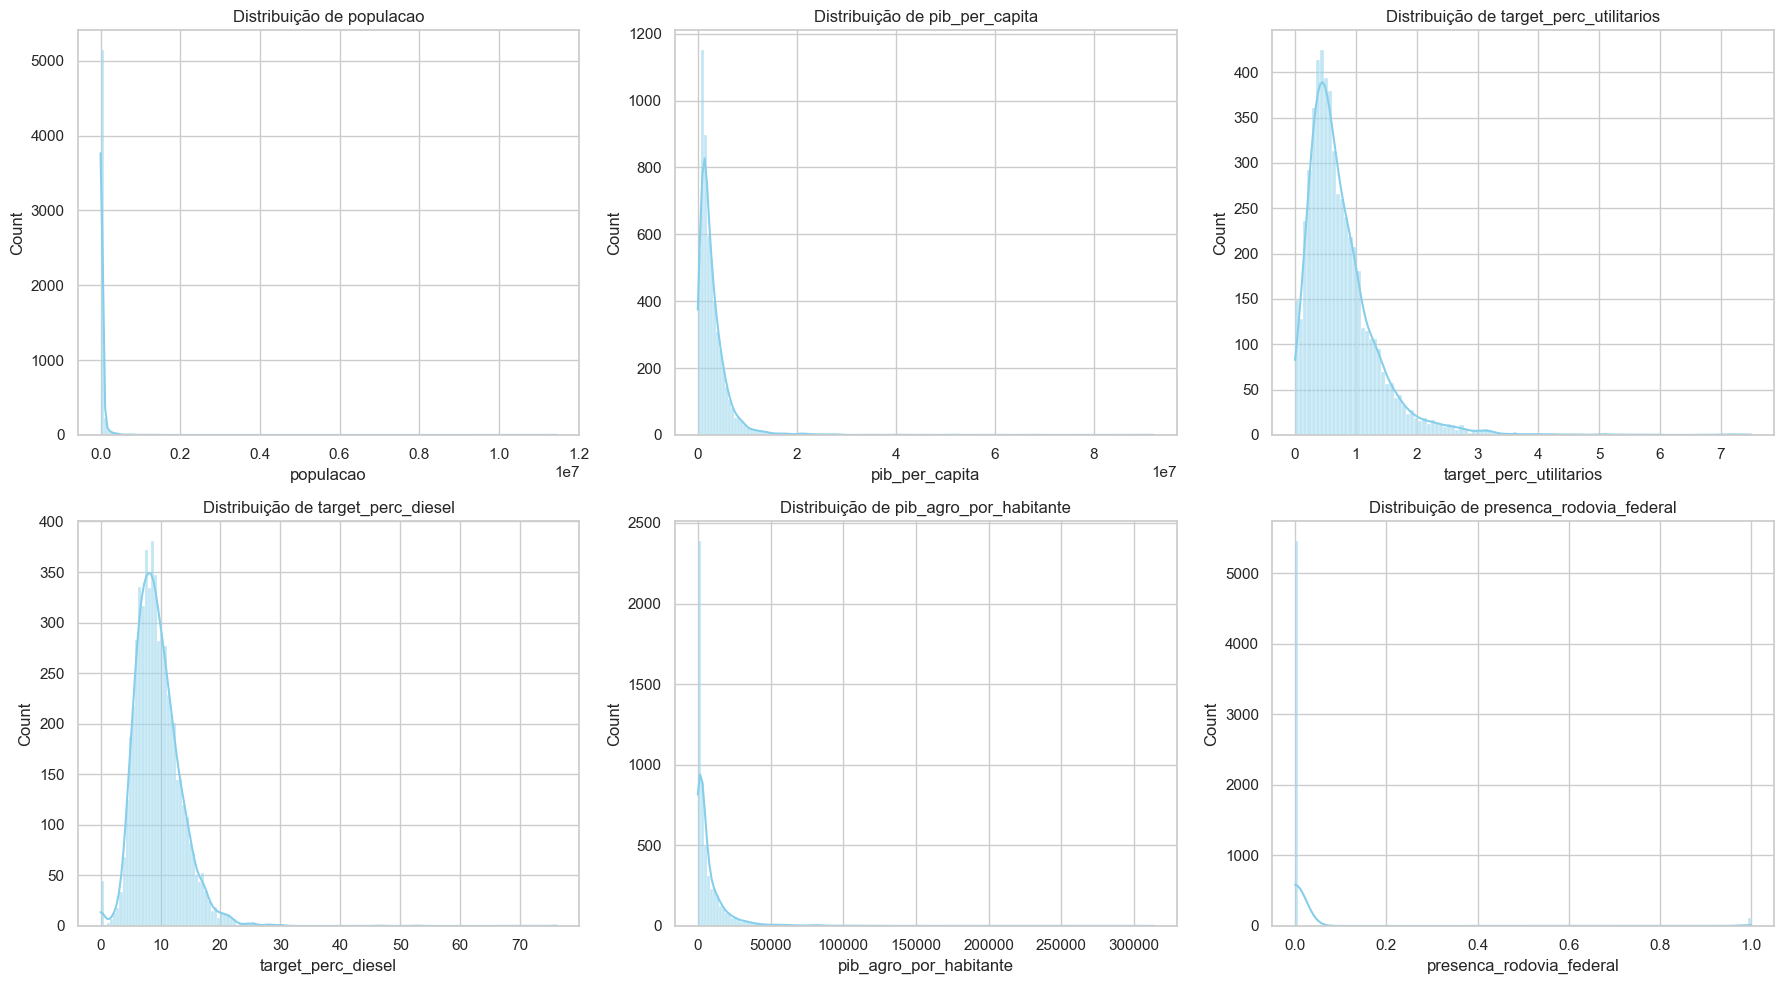

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, var in enumerate(colunas_estudo):
    sns.histplot(df[var], kde=True, ax=axes[i//3, i%3], color='skyblue')
    axes[i//3, i%3].set_title(f'Distribuição de {var}')
plt.tight_layout()

### Dependencia do Diesel (Target Perc Diesel)

A maioria das cidades tem entre 5% e 15% de frota diesel.O municipio de RONDOLANDIA no MT é um município um município que é extremamente dependente de diesel

### 

In [33]:
df.nlargest(1, 'target_perc_diesel')

,codigo,municipio,populacao,area,uf,municipio_limpo,chave_merge,densidade_demografica,vab_agro,vab_industria,...,DIESEL,FLEX,extensao_total_km,km_pavimentado,km_terra,presenca_rodovia_federal,target_perc_utilitarios,target_perc_diesel,pib_agro_por_habitante,km_terra_por_habitante
5294,5107578,Rondolândia (MT),3505.0,12658.341,MT,RONDOLANDIA,RONDOLANDIA_MT,0.276893,55094898.0,7291321.0,...,1495.0,185.0,0.0,0.0,0.0,0,0.508906,76.081425,15718.943795,0.0


## Célula 4: Detecção de Outliers (Boxplots)

Identificação de municípios com comportamentos discrepantes (ex: cidades com frota diesel desproporcional à população).

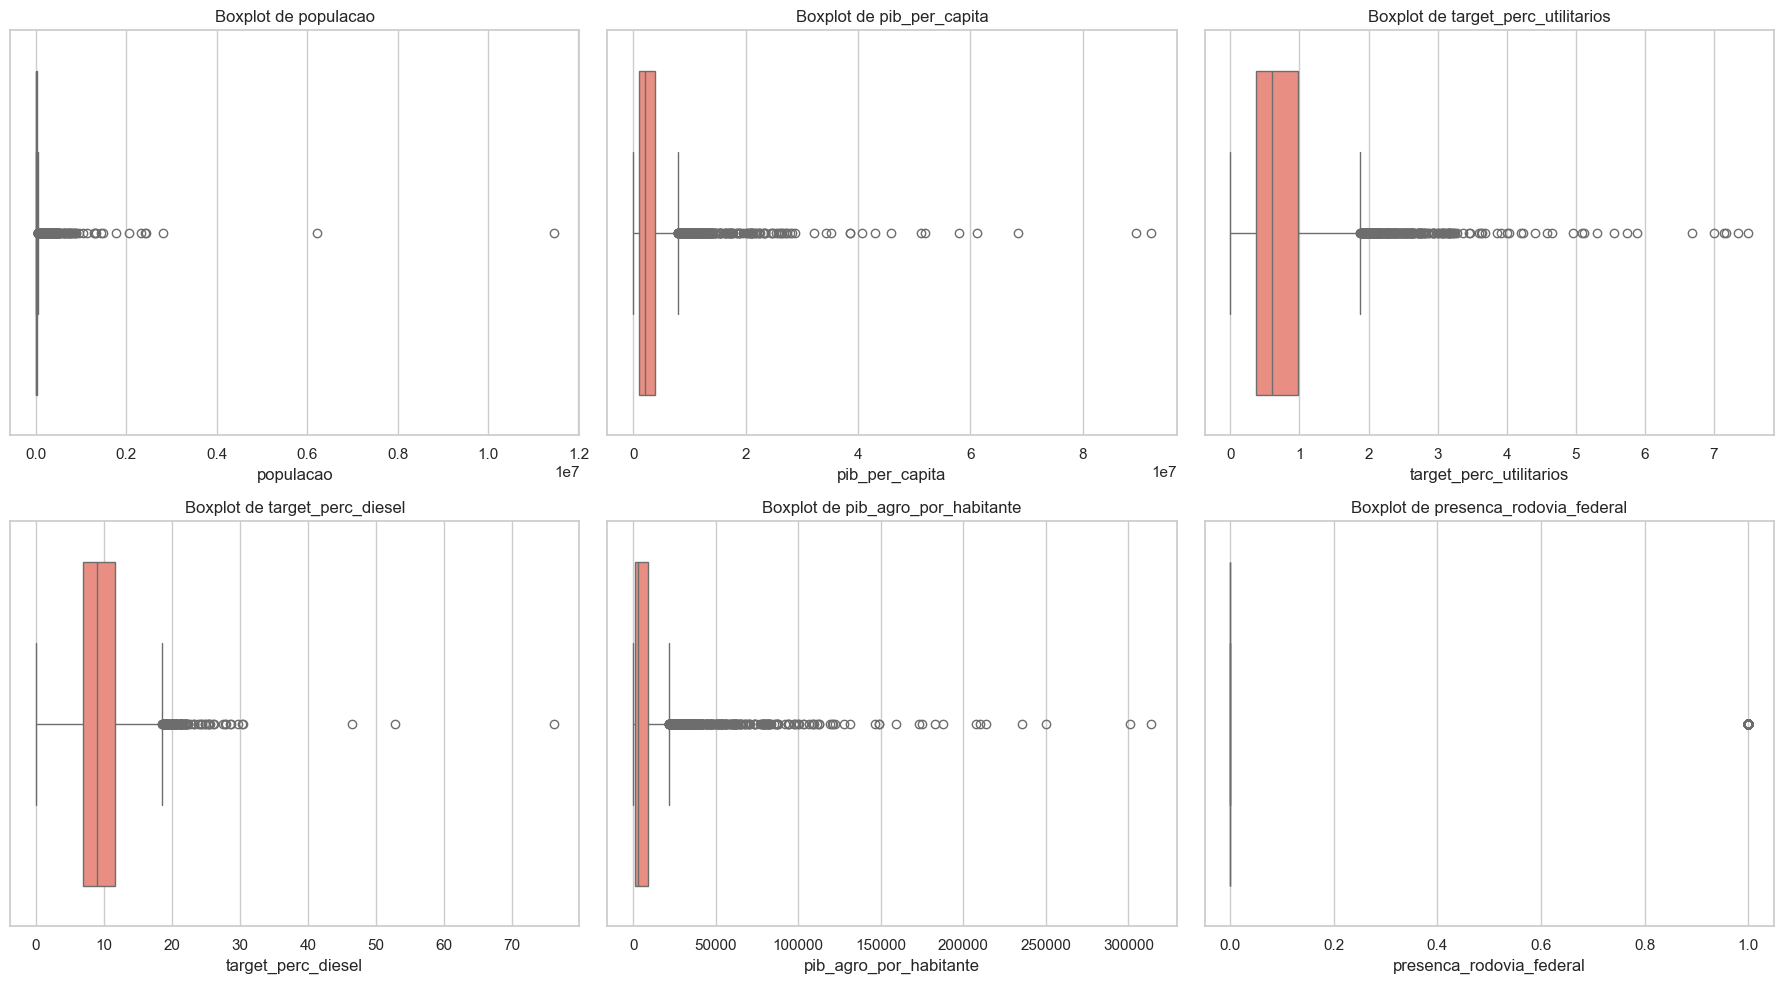

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, var in enumerate(colunas_estudo):
    sns.boxplot(x=df[var], ax=axes[i//3, i%3], color='salmon')
    axes[i//3, i%3].set_title(f'Boxplot de {var}')
plt.tight_layout()

### Target Diesel
RONDOLANDIA em MT é um município onde quase toda a frota é diesel. Isso pode ser uma cidade de fronteira, um polo logístico isolado ou uma cidade com frota agrícola massiva.

In [35]:
df.nlargest(1, 'target_perc_diesel')

,codigo,municipio,populacao,area,uf,municipio_limpo,chave_merge,densidade_demografica,vab_agro,vab_industria,...,DIESEL,FLEX,extensao_total_km,km_pavimentado,km_terra,presenca_rodovia_federal,target_perc_utilitarios,target_perc_diesel,pib_agro_por_habitante,km_terra_por_habitante
5294,5107578,Rondolândia (MT),3505.0,12658.341,MT,RONDOLANDIA,RONDOLANDIA_MT,0.276893,55094898.0,7291321.0,...,1495.0,185.0,0.0,0.0,0.0,0,0.508906,76.081425,15718.943795,0.0


## Célula 5: Matriz de Correlação (Heatmap)

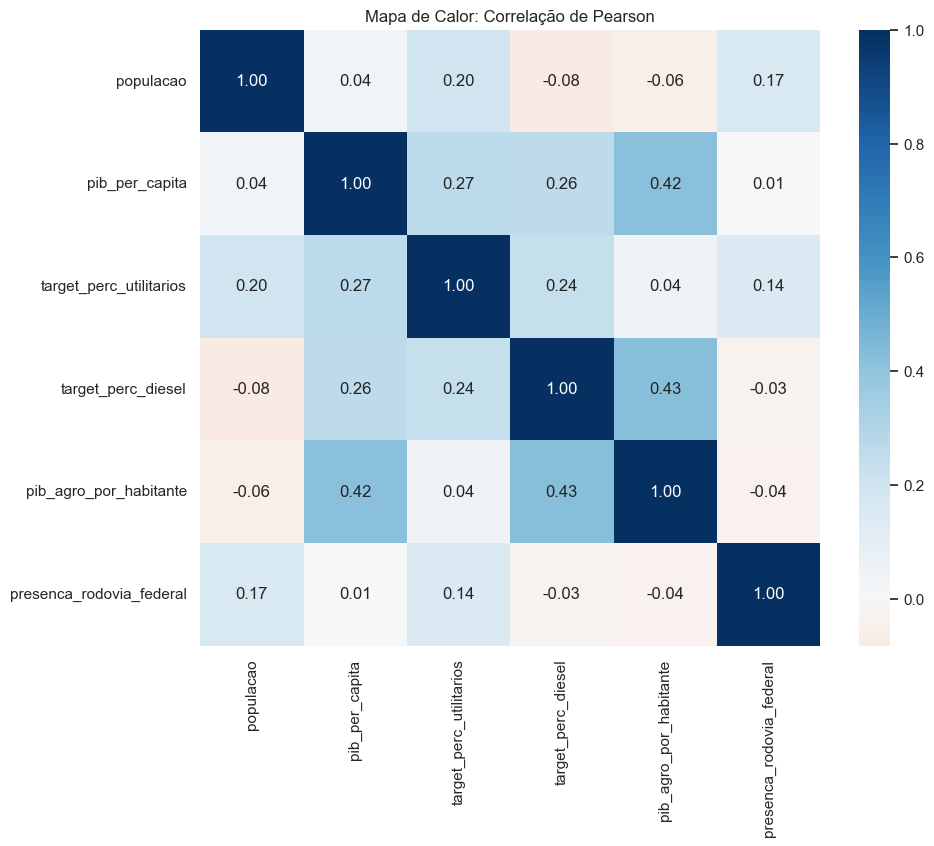

In [36]:
plt.figure(figsize=(10, 8))
corr = df[colunas_estudo].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Mapa de Calor: Correlação de Pearson')
plt.show()